Using device: cuda
✅ Part B: /kaggle/input/datasets/sethu2954/isic2019-fl-part-b
  ✅ meta.json
  ✅ test_df.csv
  ✅ train_df.csv
  ✅ fl_results_all_methods.csv
  ✅ ablation_results.csv
  ✅ final_model_fedavg.pth
  ✅ final_model_weighted_fedavg.pth
  ✅ final_model_fedprox.pth
  ✅ final_model_ditto.pth

Train:18605 | Test:4652
Client sizes: [5304, 11772, 1529]
Found 25331 images.

Loading FL models...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


  ✅ fedavg → F1=0.5373  Acc=0.7182
  ✅ weighted_fedavg → F1=0.4037  Acc=0.6786
  ✅ fedprox → F1=0.5728  Acc=0.7238
  ✅ ditto → F1=0.5658  Acc=0.7193

Training centralized model (3 epochs, streaming)...


Centralized → F1=0.6229  Acc=0.7031

Training local-only models (streaming)...


  C0 local → F1=0.3816  Acc=0.6148


  C1 local → F1=0.3468  Acc=0.6266


  C2 local → F1=0.3708  Acc=0.6060

Computing Grad-CAM IoU (50 images per method)...
  fedavg: avg=0.4739  per-client=['0.467', '0.412', '0.543']
  weighted_fedavg: avg=0.4414  per-client=['0.447', '0.529', '0.348']
  fedprox: avg=0.4858  per-client=['0.484', '0.448', '0.525']
  ditto: avg=0.4884  per-client=['0.551', '0.420', '0.494']

===== FINAL TEST METRICS =====
Method                    Acc      F1       G-mean     BalAcc     IoU
---------------------------------------------------------------------------
Centralized               0.7031   0.6229   0.6315     0.6454     N/A
Best Local (C0)           0.6148   0.3816   0.1933     0.4163     N/A
fedavg                    0.7182   0.5373   0.4818     0.5193     0.4739
weighted_fedavg           0.6786   0.4037   0.2396     0.3822     0.4414
fedprox                   0.7238   0.5728   0.5196     0.5467     0.4858
ditto                     0.7193   0.5658   0.5110     0.5494     0.4884

✅ Best FL (fedprox) vs local: 50.1%


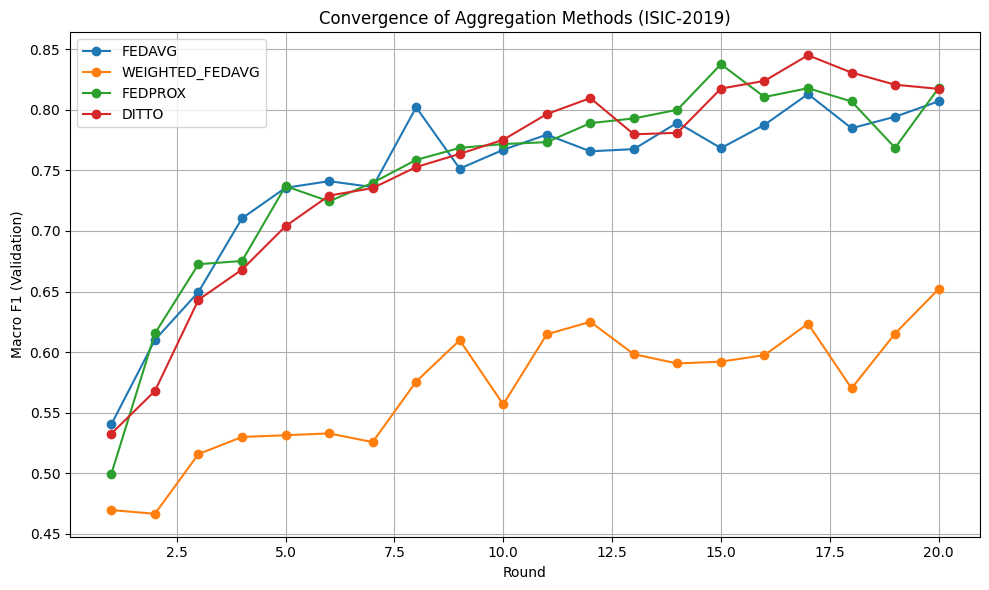

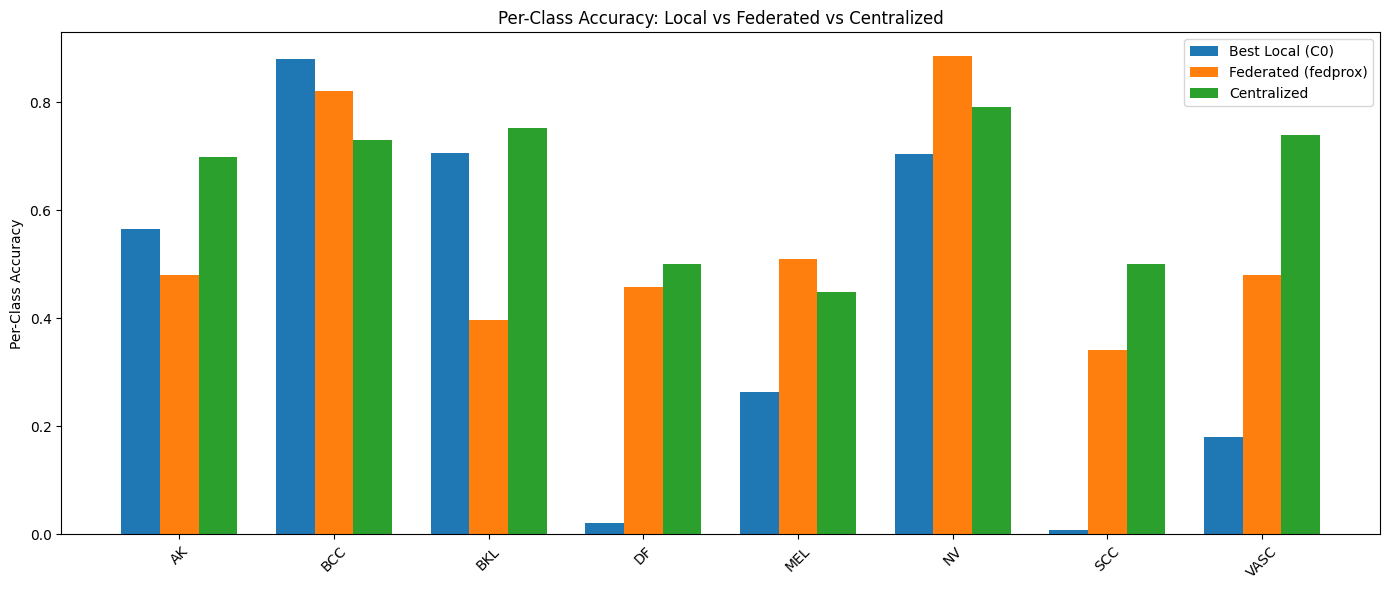

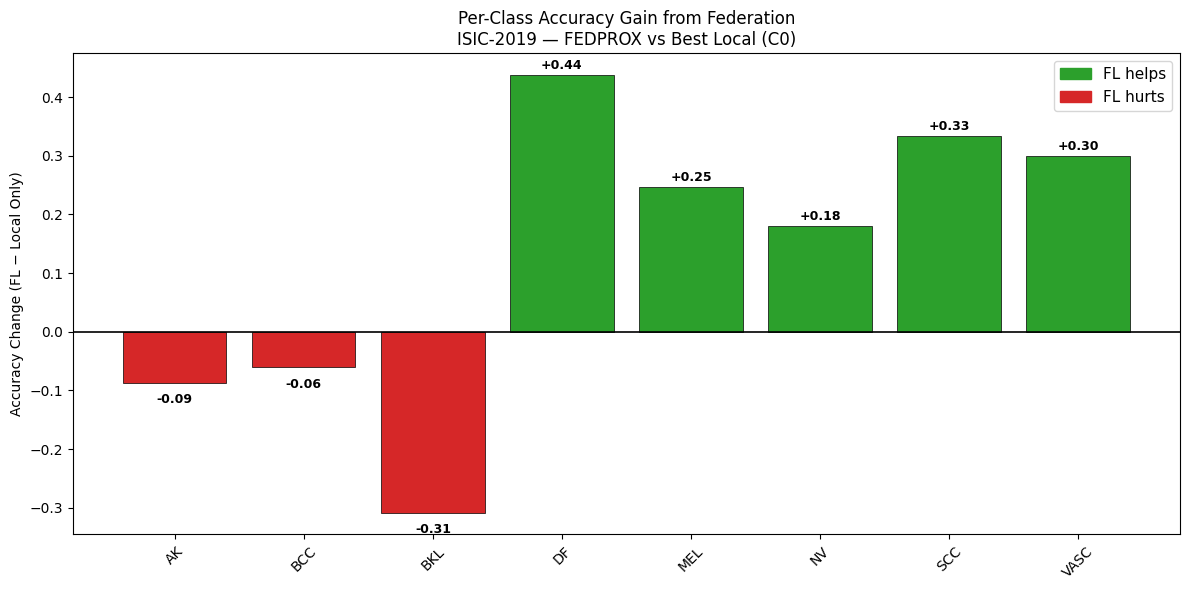

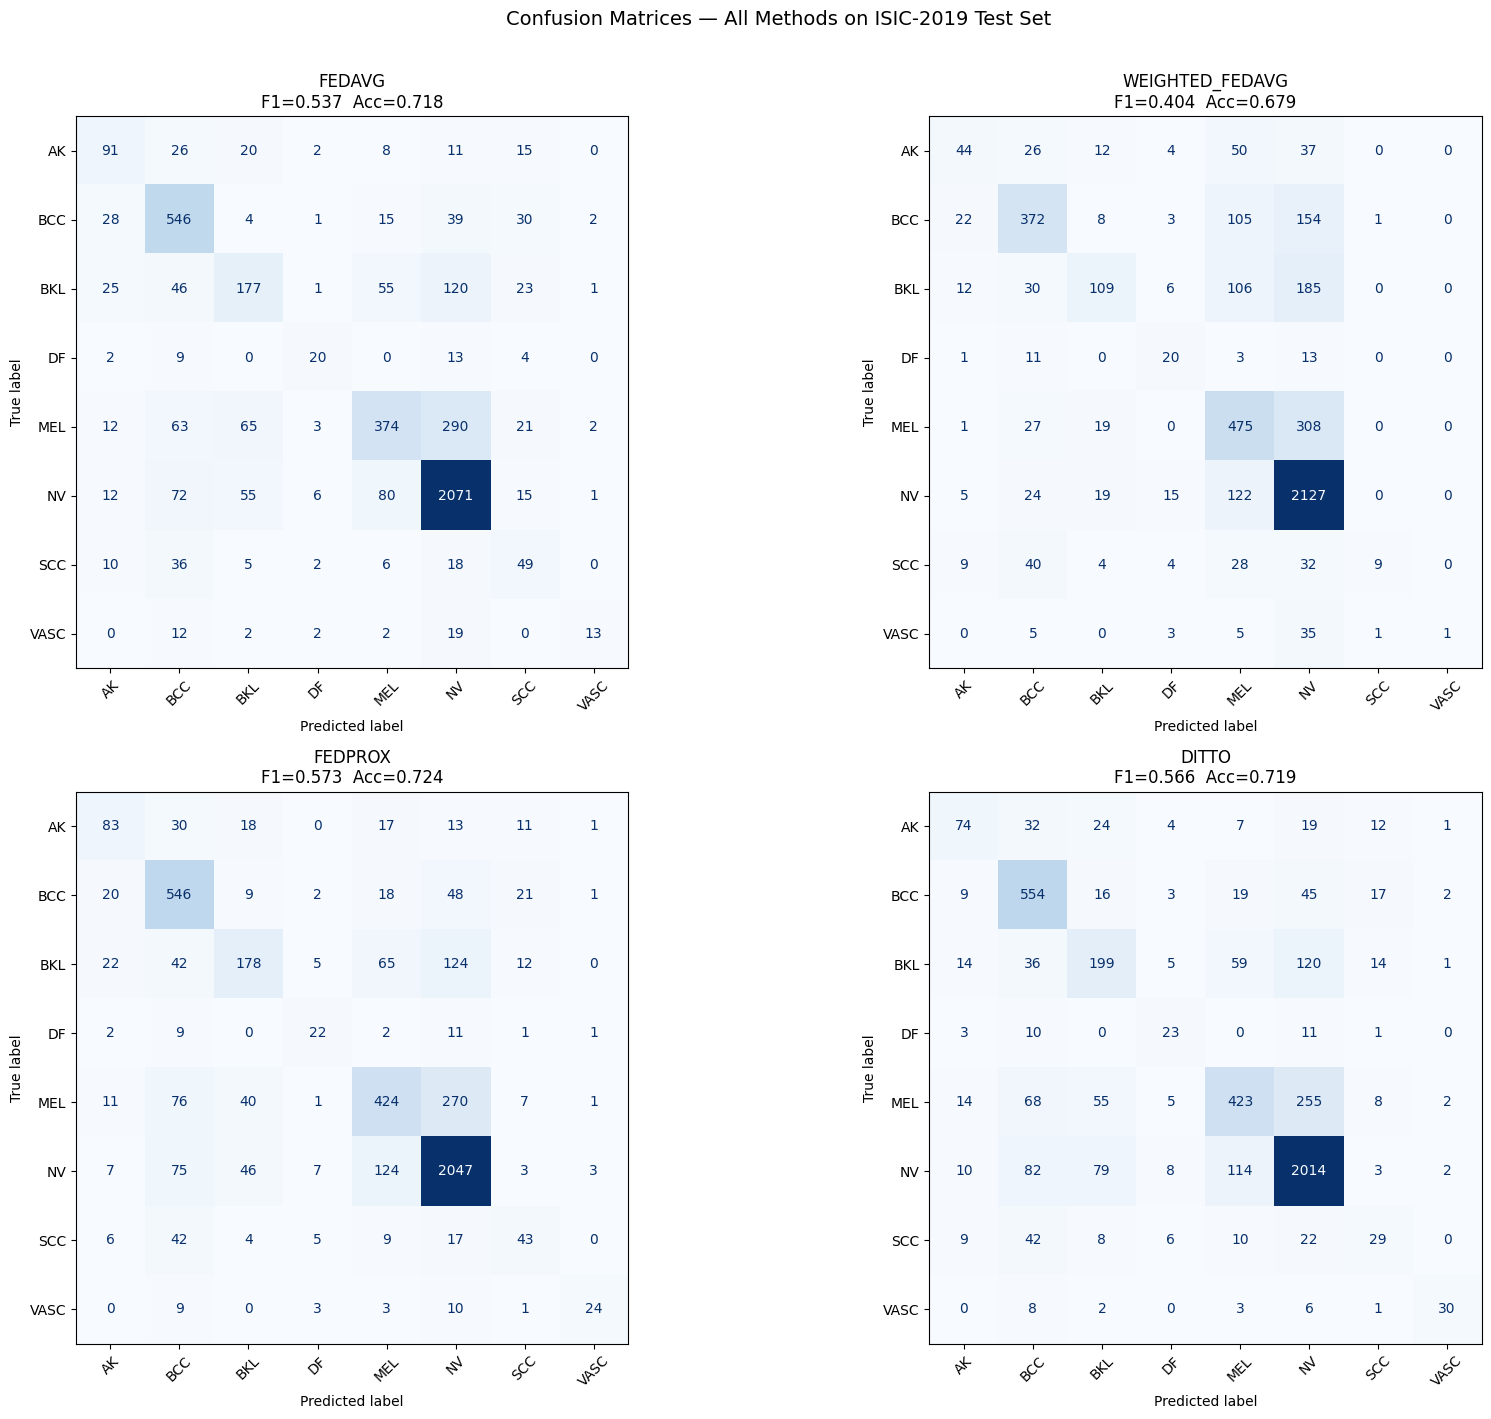

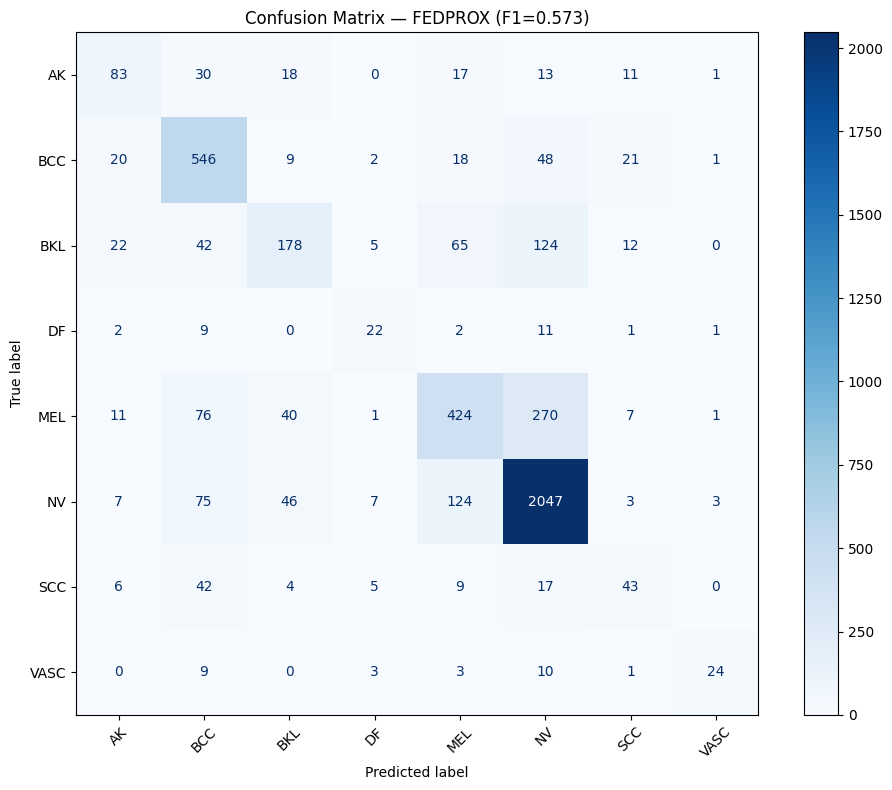

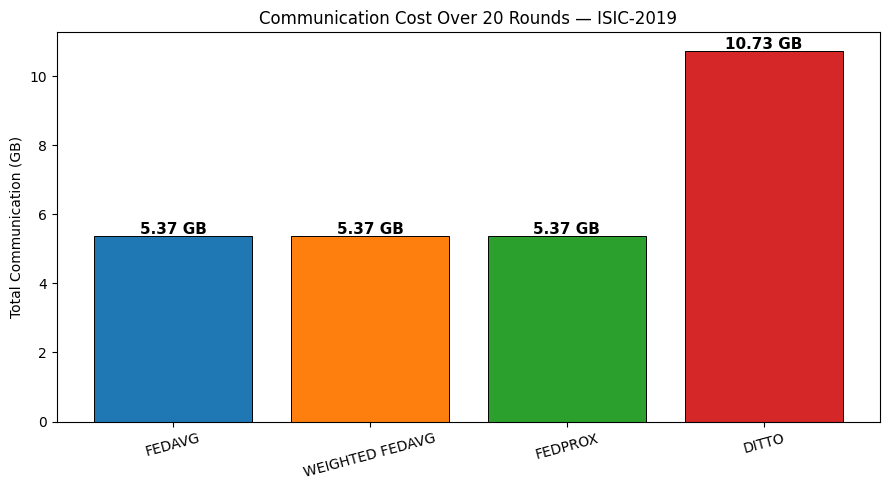

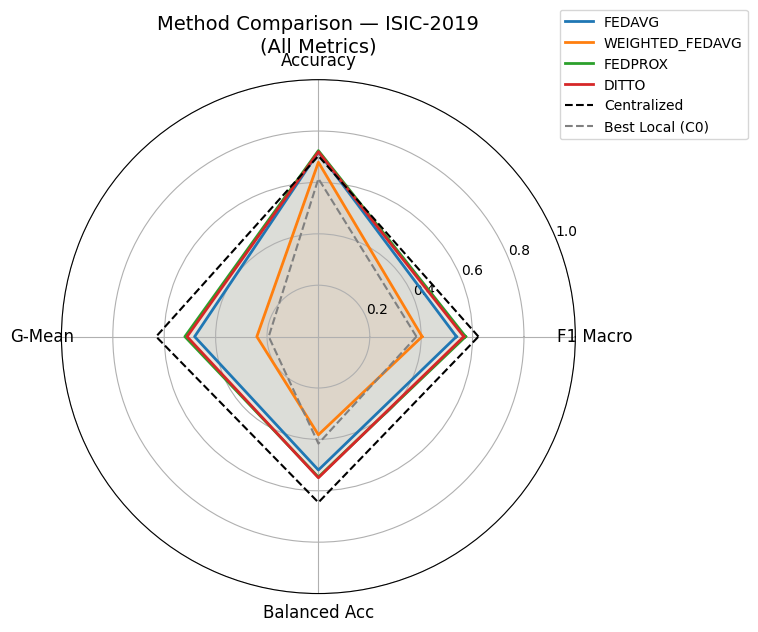

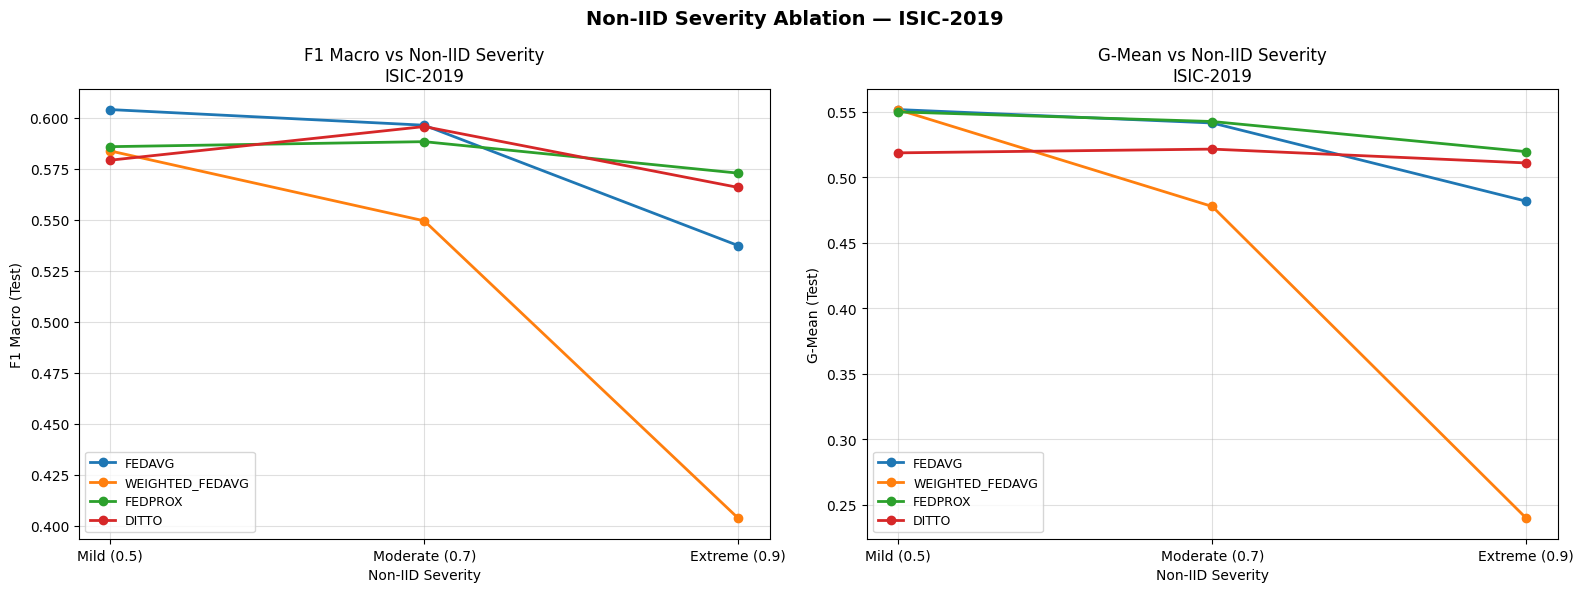


Ablation F1 pivot:
majority_frac       0.5     0.7     0.9
method                                 
ditto            0.5792  0.5956  0.5658
fedavg           0.6040  0.5963  0.5373
fedprox          0.5858  0.5882  0.5728
weighted_fedavg  0.5837  0.5494  0.4037


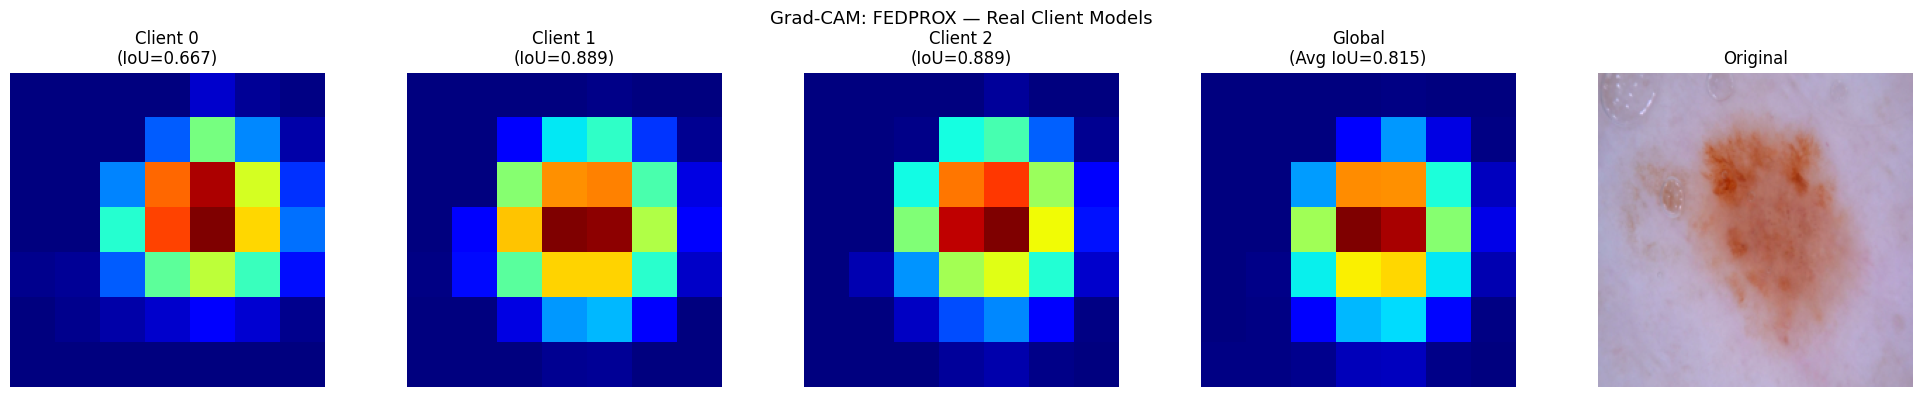


Generating CAM evolution across rounds...


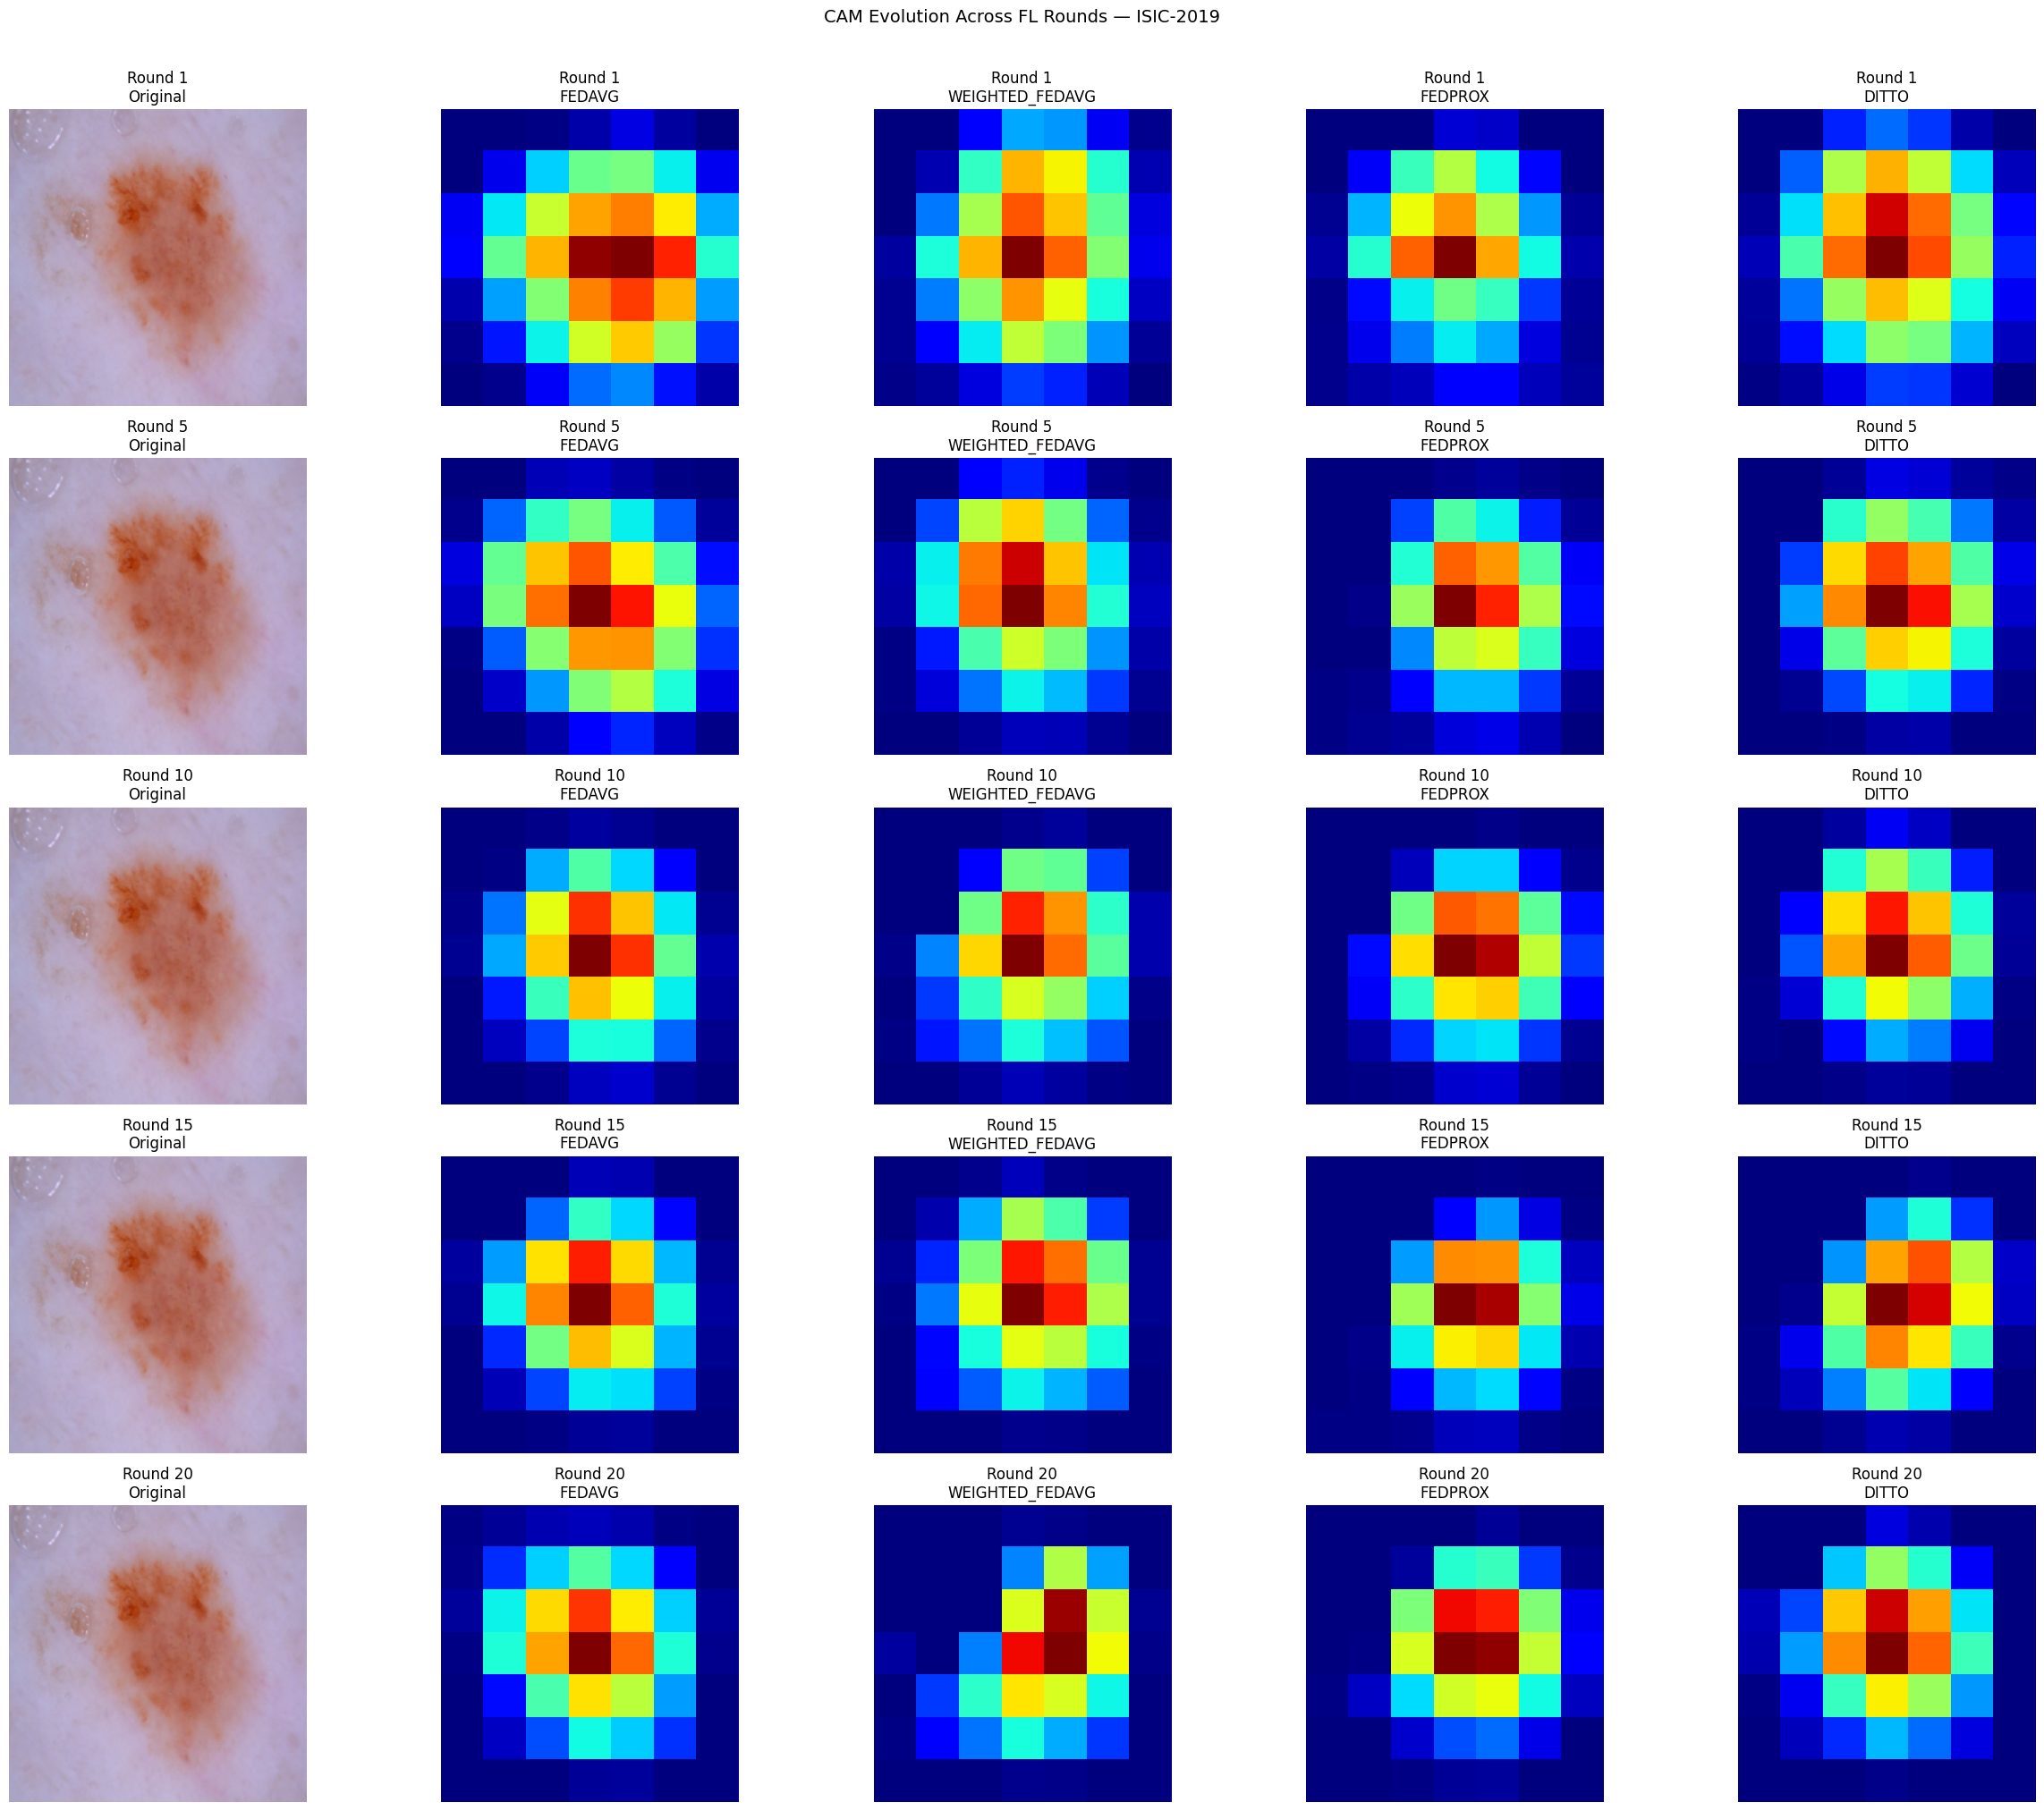

✅ CAM evolution saved.

Generating per-method CAM comparison...


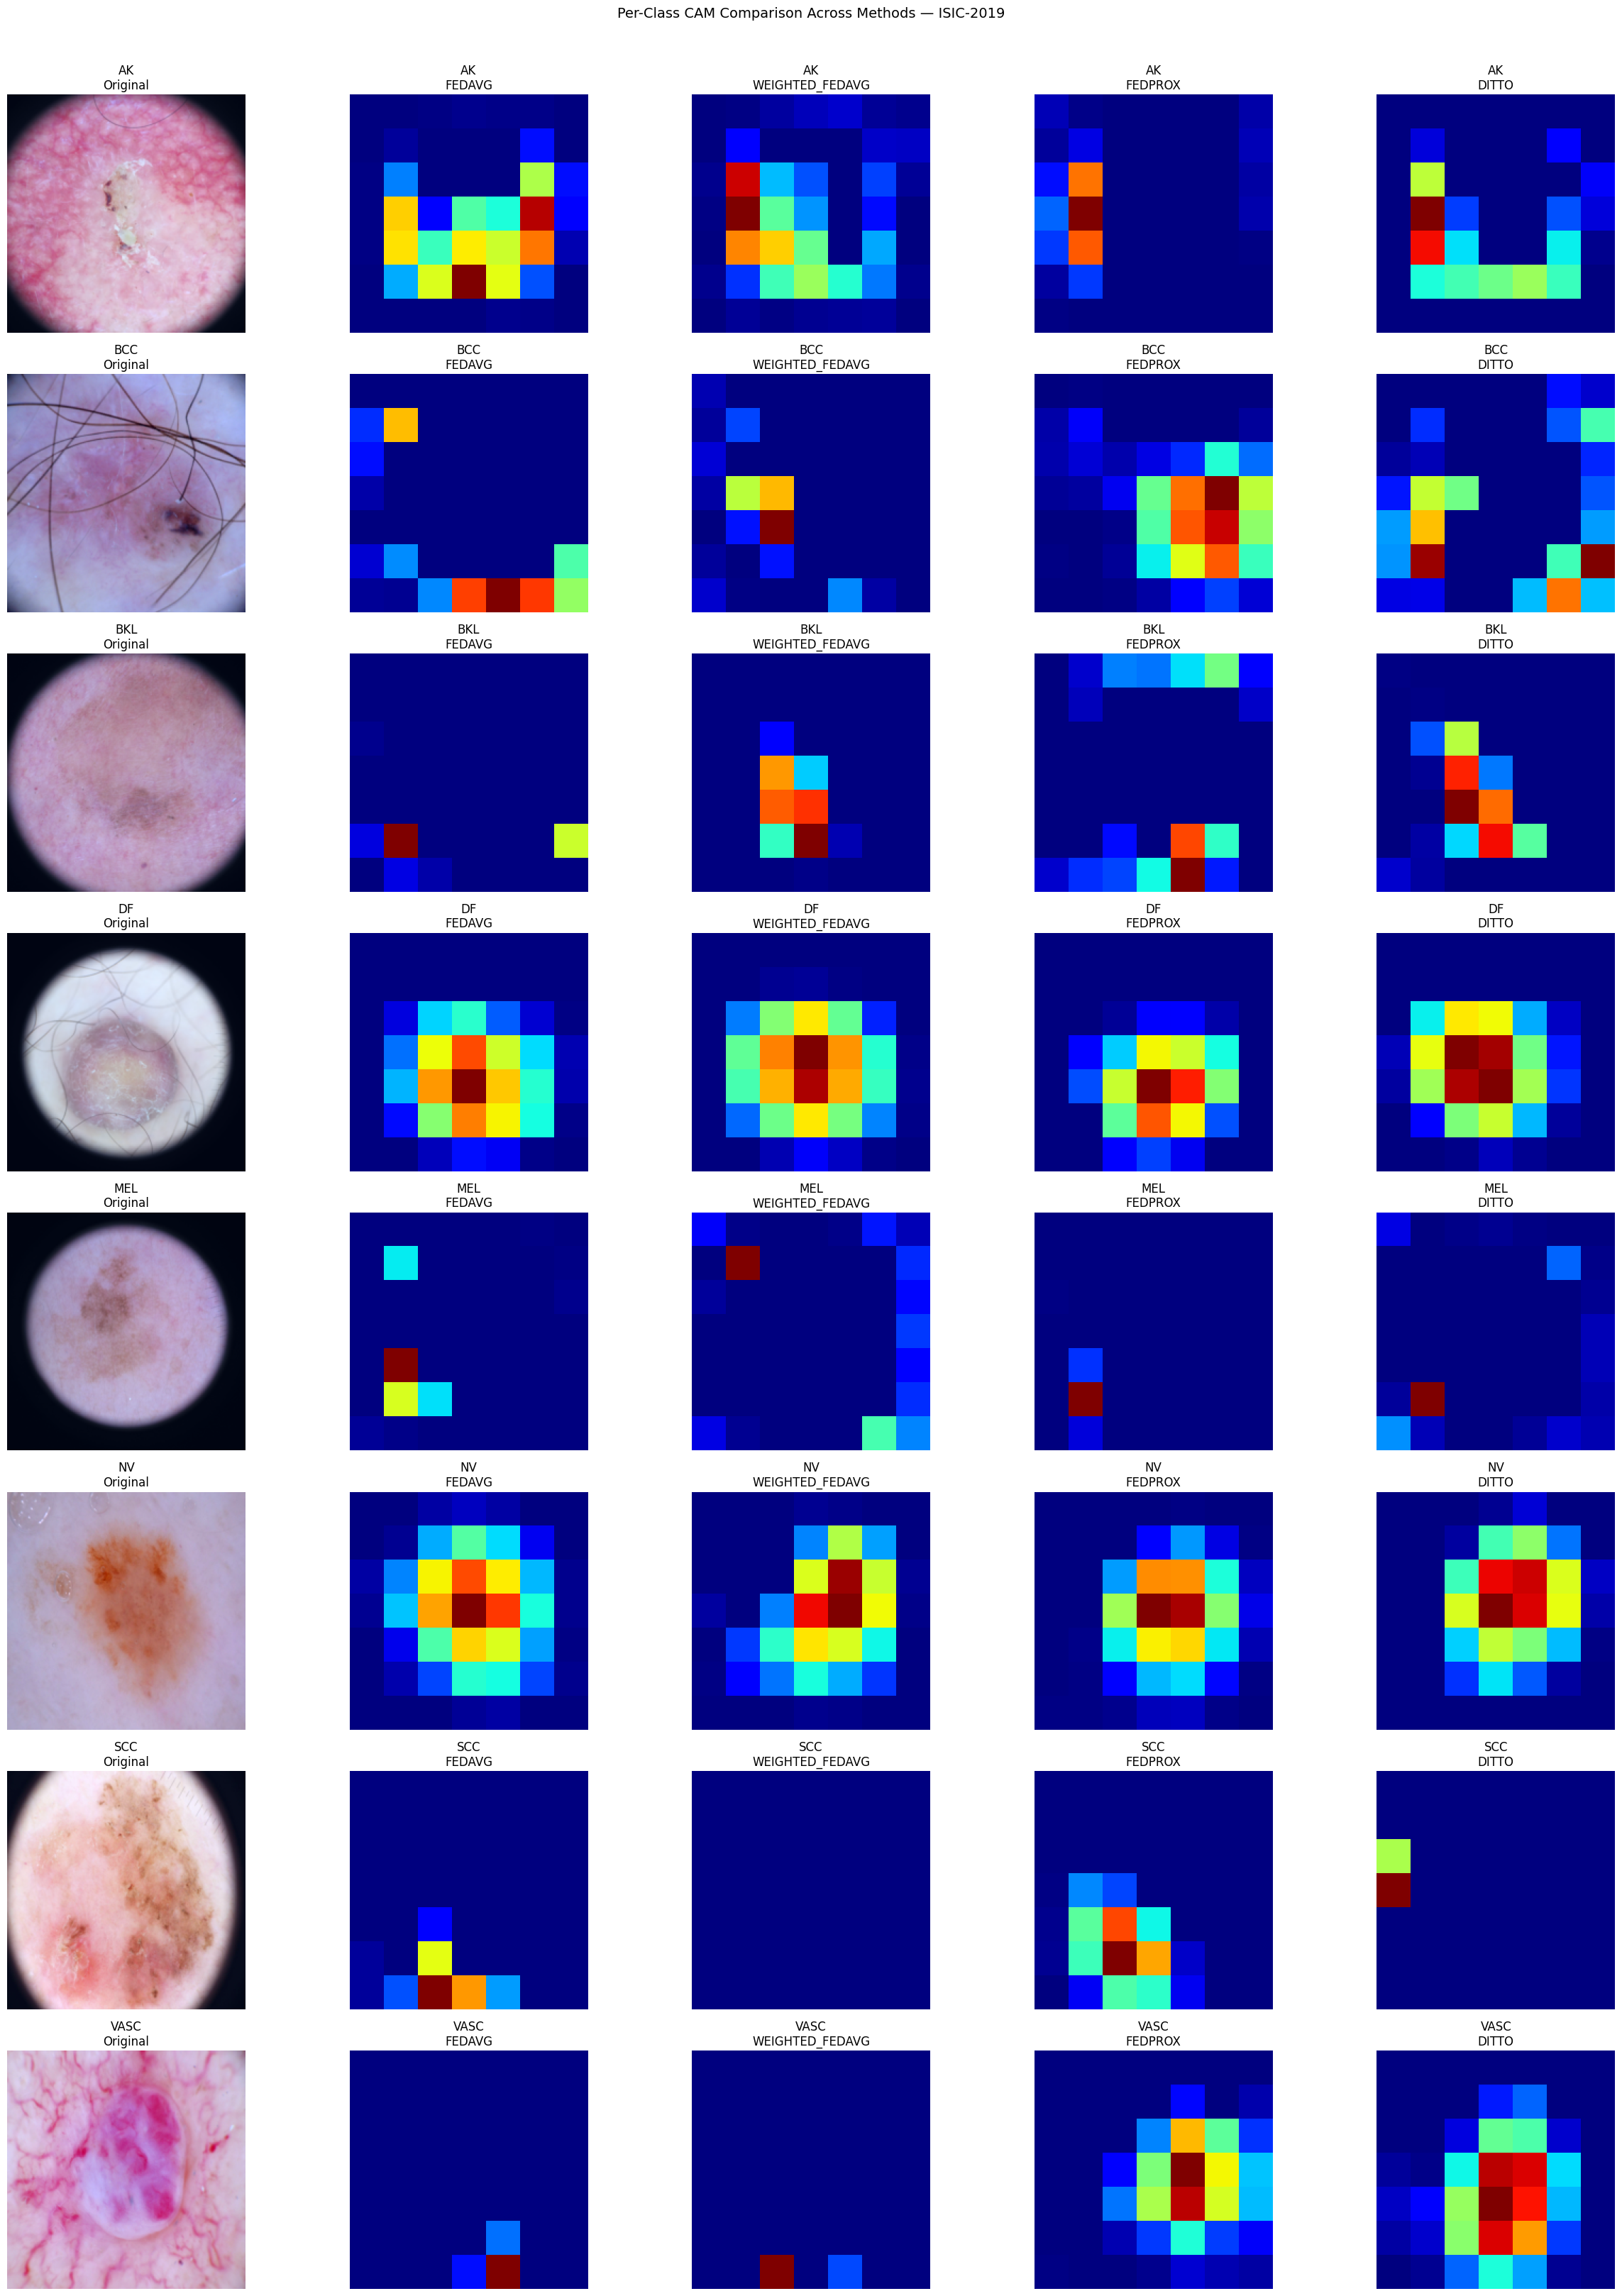

✅ Per-method CAM saved.

MACHINE UNLEARNING
Forgetting: Client 1 (dominant — DF+MEL+NV)
Base model: FEDPROX

Before unlearning:
  Forget C1 F1 : 0.6560
  Retain C0 F1   : 0.9082
  Retain C2 F1   : 0.6979
  Global F1      : 0.5728

--- Approach A: Exact Unlearning (10 rounds) ---
  Round 1/10 → val F1:0.5426
  Round 2/10 → val F1:0.6518
  Round 3/10 → val F1:0.6611
  Round 4/10 → val F1:0.6994
  Round 5/10 → val F1:0.6969
  Round 6/10 → val F1:0.7102
  Round 7/10 → val F1:0.7124
  Round 8/10 → val F1:0.7099
  Round 9/10 → val F1:0.7231
  Round 10/10 → val F1:0.7087
  Forget C1 F1 : 0.2947  (Δ=-0.3613)

--- Approach B: Gradient Ascent Unlearning ---
  Step 1: Gradient Ascent (50 steps)...
    Step 10: forget F1=0.3612
    Step 20: forget F1=0.3570
    Step 30: forget F1=0.3528
    Step 40: forget F1=0.3454
    Step 50: forget F1=0.3342
  Step 2: Fine-tune on retain (3 epochs)...
    Epoch 1: val F1=0.7795
    Epoch 2: val F1=0.7784
    Epoch 3: val F1=0.7780
  Forget C1 F1 : 0.4251  (Δ=-

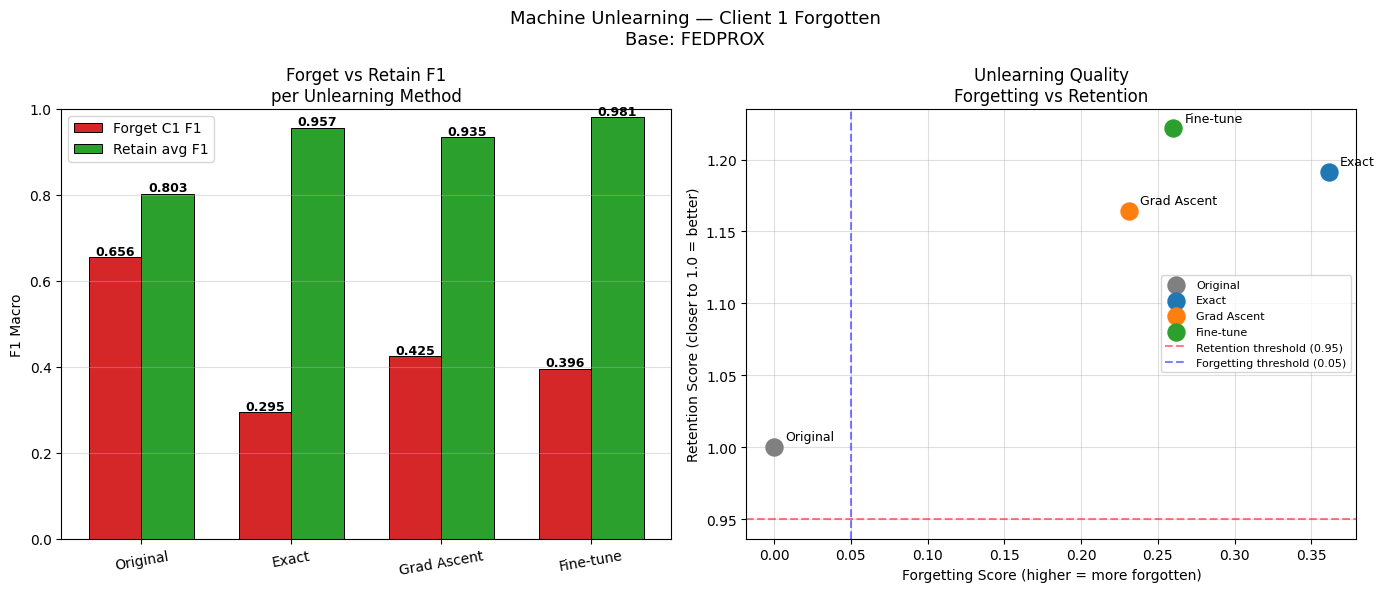

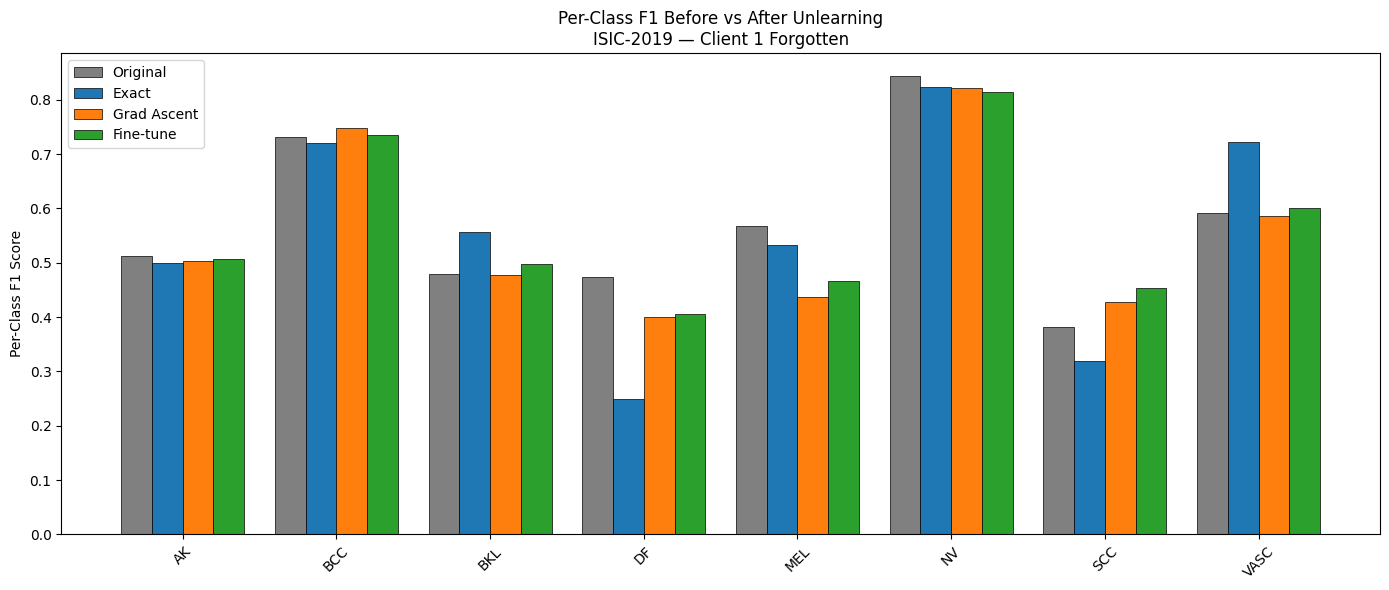


ALL OUTPUTS SAVED
  ✅ final_comparison_table.csv
  ✅ unlearning_results.csv
  ✅ ablation_pivot.csv
  ✅ communication_cost.csv
  ✅ convergence_clean.png
  ✅ per_class_comparison.png
  ✅ fl_gain_per_class.png
  ✅ confusion_matrices_all.png
  ✅ confusion_matrix_best.png
  ✅ communication_cost.png
  ✅ radar_chart.png
  ✅ ablation_severity.png
  ✅ gradcam_real_clients.png
  ✅ cam_evolution.png
  ✅ cam_per_method_comparison.png
  ✅ unlearning_comparison.png
  ✅ unlearning_per_class_f1.png


In [1]:
# ==========================================
# NOTEBOOK 2: ISIC-2019 VALIDATION
# Includes: comparison table, Grad-CAM IoU,
#   per-class analysis, confusion matrices,
#   communication cost, radar chart, ablation,
#   machine unlearning, CAM evolution,
#   per-method CAM comparison
# Input: isic2019-fl-part-b + ISIC-2019 dataset
# ==========================================

!pip install -q scikit-learn torchmetrics tqdm

import os, json, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from collections import OrderedDict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. PATHS
# ==========================================
PART_B   = "/kaggle/input/datasets/sethu2954/isic2019-fl-part-b"
DATA_DIR = "/kaggle/input/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification"

print(f"✅ Part B: {PART_B}")

# Verify key files
for fname in [
    "meta.json","test_df.csv","train_df.csv",
    "fl_results_all_methods.csv","ablation_results.csv",
    "final_model_fedavg.pth","final_model_weighted_fedavg.pth",
    "final_model_fedprox.pth","final_model_ditto.pth",
]:
    status="✅" if os.path.exists(os.path.join(PART_B,fname)) else "❌"
    print(f"  {status} {fname}")

# ==========================================
# 2. RELOAD META + DATA
# ==========================================
with open(os.path.join(PART_B,"meta.json")) as f:
    meta = json.load(f)

class_to_idx                = meta['class_to_idx']
class_names                 = meta['class_names']
majority_classes_per_client = meta['majority_classes_per_client']
client_sizes                = meta['client_sizes']
checkpoint_rounds           = meta['checkpoint_rounds']
num_classes                 = len(class_names)
MAIN_FRAC                   = 0.9

train_df   = pd.read_csv(os.path.join(PART_B,"train_df.csv"))
test_df    = pd.read_csv(os.path.join(PART_B,"test_df.csv"))
client_dfs = [pd.read_csv(os.path.join(PART_B,
              f"client_{i}_train.csv")) for i in range(3)]
client_sizes_loaded = [len(c) for c in client_dfs]

print(f"\nTrain:{len(train_df)} | Test:{len(test_df)}")
print(f"Client sizes: {client_sizes_loaded}")

# ==========================================
# 3. IMAGE LOADING
# ==========================================
image_paths={}
for cn in ['MEL','NV','BCC','AK','BKL','DF','VASC','SCC','UNK']:
    cd=os.path.join(DATA_DIR,cn)
    if not os.path.isdir(cd): continue
    for fname in os.listdir(cd):
        if fname.endswith('.jpg'):
            base=fname.replace('_downsampled.jpg','').replace('.jpg','')
            image_paths[base]=os.path.join(cd,fname)
print(f"Found {len(image_paths)} images.")

transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class StreamingDataset(Dataset):
    def __init__(self,df,image_paths,transform=None):
        self.df=df.reset_index(drop=True)
        self.image_paths=image_paths; self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self,idx):
        row=self.df.iloc[idx]
        try: img=Image.open(
            self.image_paths[row['image_base']]).convert("RGB")
        except: img=Image.new("RGB",(224,224))
        if self.transform: img=self.transform(img)
        return img,int(row['label'])

test_dataset = StreamingDataset(test_df,image_paths,transform)
test_loader  = DataLoader(test_dataset,batch_size=16,shuffle=False,
                          num_workers=4,pin_memory=True)

# Per-client test loaders for unlearning
client_test_loaders=[]
for i in range(3):
    cdf_test=pd.read_csv(
        os.path.join(PART_B,f"client_{i}_test_split.csv"))
    loader=DataLoader(
        StreamingDataset(cdf_test,image_paths,transform),
        batch_size=16,shuffle=False,
        num_workers=2,pin_memory=True)
    client_test_loaders.append(loader)

# ==========================================
# 4. MODEL + METRICS
# ==========================================
def get_model():
    m=models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc=nn.Linear(m.fc.in_features,num_classes)
    return m.to(device)

def evaluate_model(model,dataloader):
    model.eval()
    all_preds,all_labels=[],[]
    with torch.no_grad():
        for x,y in dataloader:
            x=x.to(device)
            preds=torch.argmax(F.softmax(model(x),dim=1),dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
    y_true=np.array(all_labels); y_pred=np.array(all_preds)
    pc_acc,pc_rec=[],[]
    for c in range(num_classes):
        idx=y_true==c
        pc_acc.append(float(np.mean(y_pred[idx]==c))
                      if idx.sum()>0 else 0.0)
        tp=np.sum((y_pred==c)&(y_true==c))
        fn=np.sum((y_pred!=c)&(y_true==c))
        pc_rec.append(tp/(tp+fn) if (tp+fn)>0 else 0.0)
    return {
        'accuracy':           float(accuracy_score(y_true,y_pred)),
        'balanced_accuracy':  float(balanced_accuracy_score(y_true,y_pred)),
        'f1_macro':           float(f1_score(y_true,y_pred,
                                   average='macro',zero_division=0)),
        'f1_per_class':       f1_score(y_true,y_pred,
                                   average=None,zero_division=0).tolist(),
        'f1_weighted':        float(f1_score(y_true,y_pred,
                                   average='weighted',zero_division=0)),
        'per_class_accuracy': pc_acc,
        'g_mean':             float(np.exp(np.mean(
                                   np.log([r+1e-8 for r in pc_rec])))),
        'y_true':             y_true.tolist(),
        'y_pred':             y_pred.tolist(),
    }

# ==========================================
# 5. GRAD-CAM + IoU
# ==========================================
def grad_cam(model,img_tensor,target_class,target_layer='layer4'):
    model.eval()
    img_t=img_tensor.unsqueeze(0).to(device).requires_grad_(True)
    grads,acts=[],[]
    def bwd(m,gi,go): grads.append(go[0])
    def fwd(m,i,o):   acts.append(o)
    tm=dict(model.named_modules()).get(target_layer)
    h1=tm.register_forward_hook(fwd)
    h2=tm.register_backward_hook(bwd)
    out=model(img_t); out[0,target_class].backward()
    h1.remove(); h2.remove()
    grad=grads[0].cpu().detach().numpy()[0]
    act =acts[0].cpu().detach().numpy()[0]
    w   =np.mean(grad,axis=(1,2))
    cam =np.maximum(np.sum([wi*a for wi,a in zip(w,act)],axis=0),0)
    cam=(cam-cam.min())/(cam.max()-cam.min()+1e-8)
    return cam

def compute_iou(m1,m2,threshold=0.5):
    b1=(m1>threshold).astype(np.uint8)
    b2=(m2>threshold).astype(np.uint8)
    inter=np.logical_and(b1,b2).sum()
    union=np.logical_or(b1,b2).sum()
    return (inter/union) if union>0 else (1.0 if inter==0 else 0.0)

def compute_avg_iou(global_model,client_models,
                    dataset,n_samples=50,threshold=0.5):
    np.random.seed(42)
    indices=np.random.choice(len(dataset),n_samples,replace=False)
    all_ious=[[] for _ in client_models]
    for idx in indices:
        img,label=dataset[idx]
        g_cam=grad_cam(global_model,img.to(device),label)
        for cid,cm in enumerate(client_models):
            c_cam=grad_cam(cm,img.to(device),label)
            all_ious[cid].append(compute_iou(g_cam,c_cam,threshold))
    per_client=[float(np.mean(v)) for v in all_ious]
    return float(np.mean(per_client)),per_client

# ==========================================
# 6. LOAD ALL 4 FL MODELS
# ==========================================
METHOD_NAMES     = ['fedavg','weighted_fedavg','fedprox','ditto']
fl_models        = {}
fl_client_models = {}
colors = {'fedavg':'#1f77b4','weighted_fedavg':'#ff7f0e',
          'fedprox':'#2ca02c','ditto':'#d62728'}

print("\nLoading FL models...")
for name in METHOD_NAMES:
    gm=get_model()
    gm.load_state_dict(torch.load(
        os.path.join(PART_B,f"final_model_{name}.pth"),
        map_location=device))
    fl_models[name]=gm
    clist=[]
    for cid in range(3):
        cm=get_model()
        cm.load_state_dict(torch.load(
            os.path.join(PART_B,f"client_{name}_{cid}.pth"),
            map_location=device))
        clist.append(cm)
    fl_client_models[name]=clist
    m=evaluate_model(gm,test_loader)
    print(f"  ✅ {name} → F1={m['f1_macro']:.4f}  "
          f"Acc={m['accuracy']:.4f}")

# ==========================================
# 7. CENTRALIZED BASELINE (streaming)
# ==========================================
print("\nTraining centralized model (3 epochs, streaming)...")

train_labels_all=train_df['label'].tolist()
class_counts=np.bincount(train_labels_all,minlength=num_classes)
c_sw=1.0/class_counts[train_labels_all]; c_sw/=c_sw.sum()
c_sampler=WeightedRandomSampler(
    torch.tensor(c_sw,dtype=torch.float32),
    len(c_sw),replacement=True)
c_loader=DataLoader(
    StreamingDataset(train_df,image_paths,transform),
    batch_size=16,sampler=c_sampler,
    num_workers=4,pin_memory=True)

class_weights_t=torch.tensor(
    1.0/class_counts/(1.0/class_counts).sum(),
    dtype=torch.float32).to(device)

central=get_model()
c_opt=optim.Adam(central.parameters(),lr=1e-4)
c_crit=nn.CrossEntropyLoss()
for epoch in range(3):
    central.train()
    for x,y in tqdm(c_loader,
                    desc=f"Central {epoch+1}",leave=False):
        x,y=x.to(device),y.to(device)
        c_opt.zero_grad(); c_crit(central(x),y).backward()
        c_opt.step()

central_metrics=evaluate_model(central,test_loader)
print(f"Centralized → F1={central_metrics['f1_macro']:.4f}  "
      f"Acc={central_metrics['accuracy']:.4f}")
del c_loader; torch.cuda.empty_cache()

# ==========================================
# 8. LOCAL-ONLY BASELINES (streaming)
# ==========================================
def disjoint_non_iid_split(labels,majority_per_client,
                            majority_frac=0.9,seed=42):
    np.random.seed(seed)
    labels_arr=np.array(labels); n_clients=len(majority_per_client)
    assigned=np.full(len(labels),-1,dtype=int)
    for class_id in range(num_classes):
        pos=np.where(labels_arr==class_id)[0].tolist()
        np.random.shuffle(pos)
        owner=next(
            (c for c,g in enumerate(majority_per_client)
             if class_id in g),0)
        n_maj=int(len(pos)*majority_frac)
        for i in pos[:n_maj]: assigned[i]=owner
        others=[c for c in range(n_clients) if c!=owner]
        for c,chunk in zip(others,
                np.array_split(pos[n_maj:],max(len(others),1))):
            for i in chunk: assigned[i]=c
    assigned[assigned==-1]=0
    return [np.where(assigned==c)[0].tolist()
            for c in range(n_clients)]

client_indices_local=disjoint_non_iid_split(
    train_labels_all,majority_classes_per_client,
    majority_frac=MAIN_FRAC)

print("\nTraining local-only models (streaming)...")
local_models,local_metrics=[],[]
NOISE_LEVELS=[0.0,20.0,10.0]

for cid,idx in enumerate(client_indices_local):
    cdf=train_df.iloc[idx].reset_index(drop=True)
    lbls=cdf['label'].values
    cnts=np.bincount(lbls,minlength=num_classes)
    sw=1.0/cnts[lbls]; sw/=sw.sum()
    samp=WeightedRandomSampler(
        torch.tensor(sw,dtype=torch.float32),
        len(sw),replacement=True)
    loader=DataLoader(
        StreamingDataset(cdf,image_paths,transform),
        batch_size=16,sampler=samp,
        num_workers=4,pin_memory=True)
    model=get_model()
    opt=optim.Adam(model.parameters(),lr=1e-4)
    crit=nn.CrossEntropyLoss()
    for epoch in range(3):
        model.train()
        for x,y in tqdm(loader,
                        desc=f"Local C{cid} ep{epoch+1}",
                        leave=False):
            x,y=x.to(device),y.to(device)
            opt.zero_grad(); crit(model(x),y).backward()
            opt.step()
    m=evaluate_model(model,test_loader)
    local_models.append(model); local_metrics.append(m)
    print(f"  C{cid} local → F1={m['f1_macro']:.4f}  "
          f"Acc={m['accuracy']:.4f}")
    del loader; torch.cuda.empty_cache()

# ==========================================
# 9. GRAD-CAM IoU (50 test images)
# ==========================================
print("\nComputing Grad-CAM IoU (50 images per method)...")
iou_results={}
for name in METHOD_NAMES:
    avg_iou,per_client=compute_avg_iou(
        fl_models[name],fl_client_models[name],
        test_dataset,n_samples=50)
    iou_results[name]={'avg':avg_iou,'per_client':per_client}
    print(f"  {name}: avg={avg_iou:.4f}  "
          f"per-client={[f'{v:.3f}' for v in per_client]}")

# ==========================================
# 10. FINAL COMPARISON TABLE
# ==========================================
best_local_idx=int(np.argmax([m['f1_macro'] for m in local_metrics]))
bl=local_metrics[best_local_idx]

print("\n===== FINAL TEST METRICS =====")
print(f"{'Method':<25} {'Acc':<8} {'F1':<8} "
      f"{'G-mean':<10} {'BalAcc':<10} {'IoU'}")
print("-"*75)

table_data=[]
for label,m,iou in (
    [('Centralized',central_metrics,None),
     (f'Best Local (C{best_local_idx})',bl,None)]+
    [(n,evaluate_model(fl_models[n],test_loader),
      iou_results[n]['avg']) for n in METHOD_NAMES]
):
    iou_s=f"{iou:.4f}" if iou else "N/A"
    print(f"{label:<25} {m['accuracy']:.4f}   "
          f"{m['f1_macro']:.4f}   {m['g_mean']:.4f}     "
          f"{m['balanced_accuracy']:.4f}     {iou_s}")
    table_data.append({
        'Method':label,'Accuracy':m['accuracy'],
        'F1_macro':m['f1_macro'],'G_mean':m['g_mean'],
        'Balanced_Acc':m['balanced_accuracy'],'IoU':iou,
    })

pd.DataFrame(table_data).to_csv(
    "/kaggle/working/final_comparison_table.csv",index=False)

best_fl_name=max(METHOD_NAMES,
    key=lambda n:evaluate_model(fl_models[n],test_loader)['f1_macro'])
best_fl_f1=evaluate_model(fl_models[best_fl_name],test_loader)['f1_macro']
print(f"\n✅ Best FL ({best_fl_name}) vs local: "
      f"{(best_fl_f1-bl['f1_macro'])/bl['f1_macro']*100:.1f}%")

# ==========================================
# 11. CONVERGENCE PLOT
# ==========================================
df_results=pd.read_csv(
    os.path.join(PART_B,"fl_results_all_methods.csv"))
plt.figure(figsize=(10,6))
for name in METHOD_NAMES:
    sub=df_results[df_results['aggregation']==name]
    if len(sub)>0:
        plt.plot(sub['round']+1,sub['f1_macro'],
                 marker='o',color=colors[name],label=name.upper())
plt.xlabel('Round'); plt.ylabel('Macro F1 (Validation)')
plt.title('Convergence of Aggregation Methods (ISIC-2019)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("/kaggle/working/convergence_clean.png",dpi=150)
plt.show()

# ==========================================
# 12. PER-CLASS COMPARISON
# ==========================================
best_fl_metrics=evaluate_model(fl_models[best_fl_name],test_loader)
x=np.arange(num_classes); w=0.25
fig,ax=plt.subplots(figsize=(14,6))
ax.bar(x-w,bl['per_class_accuracy'],w,
       label=f'Best Local (C{best_local_idx})')
ax.bar(x,  best_fl_metrics['per_class_accuracy'],w,
       label=f'Federated ({best_fl_name})')
ax.bar(x+w,central_metrics['per_class_accuracy'],w,
       label='Centralized')
ax.set_xticks(x); ax.set_xticklabels(class_names,rotation=45)
ax.set_ylabel('Per-Class Accuracy')
ax.set_title('Per-Class Accuracy: Local vs Federated vs Centralized')
ax.legend(); plt.tight_layout()
plt.savefig("/kaggle/working/per_class_comparison.png",dpi=150)
plt.show()

# ==========================================
# 13. FL GAIN PER CLASS
# ==========================================
delta=[f-l for f,l in zip(best_fl_metrics['per_class_accuracy'],
                           bl['per_class_accuracy'])]
bar_colors=['#2ca02c' if d>0 else '#d62728' for d in delta]
fig,ax=plt.subplots(figsize=(12,6))
bars=ax.bar(range(num_classes),delta,
            color=bar_colors,edgecolor='black',linewidth=0.5)
ax.axhline(0,color='black',linewidth=1.2)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names,rotation=45)
ax.set_ylabel('Accuracy Change (FL − Local Only)')
ax.set_title(f'Per-Class Accuracy Gain from Federation\n'
             f'ISIC-2019 — {best_fl_name.upper()} vs '
             f'Best Local (C{best_local_idx})')
for bar,d in zip(bars,delta):
    ypos=bar.get_height()+0.01 if d>=0 else bar.get_height()-0.035
    ax.text(bar.get_x()+bar.get_width()/2,ypos,
            f'{d:+.2f}',ha='center',fontsize=9,fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#2ca02c',label='FL helps'),
    mpatches.Patch(color='#d62728',label='FL hurts'),
],fontsize=11)
plt.tight_layout()
plt.savefig("/kaggle/working/fl_gain_per_class.png",dpi=150)
plt.show()

# ==========================================
# 14. CONFUSION MATRICES
# ==========================================
fig,axes=plt.subplots(2,2,figsize=(18,14))
axes=axes.flatten()
for ax,name in zip(axes,METHOD_NAMES):
    m=evaluate_model(fl_models[name],test_loader)
    cm_mat=confusion_matrix(m['y_true'],m['y_pred'])
    ConfusionMatrixDisplay(cm_mat,display_labels=class_names).plot(
        ax=ax,cmap='Blues',xticks_rotation=45,colorbar=False)
    ax.set_title(f'{name.upper()}\n'
                 f'F1={m["f1_macro"]:.3f}  Acc={m["accuracy"]:.3f}')
plt.suptitle('Confusion Matrices — All Methods on ISIC-2019 Test Set',
             fontsize=14,y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices_all.png",
            dpi=150,bbox_inches='tight')
plt.show()

best_m=evaluate_model(fl_models[best_fl_name],test_loader)
cm_mat=confusion_matrix(best_m['y_true'],best_m['y_pred'])
fig,ax=plt.subplots(figsize=(10,8))
ConfusionMatrixDisplay(cm_mat,display_labels=class_names).plot(
    ax=ax,cmap='Blues',xticks_rotation=45,colorbar=True)
ax.set_title(f'Confusion Matrix — {best_fl_name.upper()} '
             f'(F1={best_m["f1_macro"]:.3f})')
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_best.png",dpi=150)
plt.show()

# ==========================================
# 15. COMMUNICATION COST
# ==========================================
def comm_cost(rounds=20,n_clients=3,multiplier=1):
    params=sum(p.numel() for p in get_model().parameters())
    return (params*4*2*n_clients*rounds*multiplier)/1e9

color_list=['#1f77b4','#ff7f0e','#2ca02c','#d62728']
costs=[comm_cost(multiplier=2 if n=='ditto' else 1)
       for n in METHOD_NAMES]
fig,ax=plt.subplots(figsize=(9,5))
bars=ax.bar(METHOD_NAMES,costs,color=color_list,
            edgecolor='black',linewidth=0.7)
for bar,val in zip(bars,costs):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.05,
            f'{val:.2f} GB',ha='center',
            fontsize=11,fontweight='bold')
ax.set_ylabel('Total Communication (GB)')
ax.set_title('Communication Cost Over 20 Rounds — ISIC-2019')
ax.set_xticklabels(
    [n.replace('_',' ').upper() for n in METHOD_NAMES],rotation=15)
plt.tight_layout()
plt.savefig("/kaggle/working/communication_cost.png",dpi=150)
plt.show()

pd.DataFrame([{
    'Method':n,
    'Total_GB':f"{comm_cost(multiplier=2 if n=='ditto' else 1):.2f}",
    'Note':'2× (global+personal)' if n=='ditto' else 'standard'
} for n in METHOD_NAMES]).to_csv(
    "/kaggle/working/communication_cost.csv",index=False)

# ==========================================
# 16. RADAR CHART
# ==========================================
radar_metrics=['F1 Macro','Accuracy','G-Mean','Balanced Acc']
n=len(radar_metrics)
angles=np.linspace(0,2*np.pi,n,endpoint=False).tolist()
angles+=angles[:1]
fig,ax=plt.subplots(figsize=(8,8),subplot_kw=dict(polar=True))
for name,color in zip(METHOD_NAMES,color_list):
    m=evaluate_model(fl_models[name],test_loader)
    vals=[m['f1_macro'],m['accuracy'],
          m['g_mean'],  m['balanced_accuracy']]
    vals+=vals[:1]
    ax.plot(angles,vals,color=color,linewidth=2,label=name.upper())
    ax.fill(angles,vals,color=color,alpha=0.08)
for ref,label,clr in [
    (central_metrics,'Centralized','black'),
    (bl,f'Best Local (C{best_local_idx})','grey')]:
    vals=[ref['f1_macro'],ref['accuracy'],
          ref['g_mean'],  ref['balanced_accuracy']]
    vals+=vals[:1]
    ax.plot(angles,vals,color=clr,linewidth=1.5,
            linestyle='--',label=label)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics,size=12)
ax.set_ylim(0,1)
ax.set_title('Method Comparison — ISIC-2019\n(All Metrics)',
             size=14,pad=20)
ax.legend(loc='upper right',bbox_to_anchor=(1.35,1.15),fontsize=10)
plt.tight_layout()
plt.savefig("/kaggle/working/radar_chart.png",
            dpi=150,bbox_inches='tight')
plt.show()

# ==========================================
# 17. ABLATION SEVERITY PLOT
# ==========================================
df_abl=pd.read_csv(os.path.join(PART_B,"ablation_results.csv"))
frac_labels={0.5:'Mild (0.5)',0.7:'Moderate (0.7)',
             0.9:'Extreme (0.9)'}
fig,axes=plt.subplots(1,2,figsize=(16,6))
for ax,metric,ylabel in zip(
        axes,['f1_macro','g_mean'],
        ['F1 Macro (Test)','G-Mean (Test)']):
    for name in METHOD_NAMES:
        sub=df_abl[df_abl['method']==name].sort_values('majority_frac')
        ax.plot(
            [frac_labels.get(f,str(f)) for f in sub['majority_frac']],
            sub[metric],marker='o',color=colors[name],
            linewidth=2,label=name.upper())
    ax.set_xlabel('Non-IID Severity'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(True,alpha=0.4)
axes[0].set_title('F1 Macro vs Non-IID Severity\nISIC-2019')
axes[1].set_title('G-Mean vs Non-IID Severity\nISIC-2019')
plt.suptitle('Non-IID Severity Ablation — ISIC-2019',
             fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/ablation_severity.png",dpi=150)
plt.show()

pivot=df_abl.pivot_table(
    index='method',columns='majority_frac',
    values='f1_macro').round(4)
pivot.to_csv("/kaggle/working/ablation_pivot.csv")
print("\nAblation F1 pivot:"); print(pivot.to_string())

# ==========================================
# 18. GRAD-CAM VISUALISATION (sample image)
# ==========================================
sample_img,sample_label=test_dataset[0]
global_cam=grad_cam(fl_models[best_fl_name],
                    sample_img.to(device),sample_label)
client_cams,client_ious=[],[]
for cm in fl_client_models[best_fl_name]:
    c_cam=grad_cam(cm,sample_img.to(device),sample_label)
    client_cams.append(c_cam)
    client_ious.append(compute_iou(global_cam,c_cam))
avg_iou_s=float(np.mean(client_ious))

fig,axes=plt.subplots(1,5,figsize=(20,4))
for i,(cam,iou) in enumerate(zip(client_cams,client_ious)):
    axes[i].imshow(cam,cmap='jet')
    axes[i].set_title(f'Client {i}\n(IoU={iou:.3f})')
    axes[i].axis('off')
axes[3].imshow(global_cam,cmap='jet')
axes[3].set_title(f'Global\n(Avg IoU={avg_iou_s:.3f})')
axes[3].axis('off')
orig=sample_img.permute(1,2,0).numpy()
orig=(orig-orig.min())/(orig.max()-orig.min())
axes[4].imshow(orig); axes[4].set_title('Original'); axes[4].axis('off')
plt.suptitle(f'Grad-CAM: {best_fl_name.upper()} — Real Client Models',
             fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/gradcam_real_clients.png",dpi=150)
plt.show()

# ==========================================
# 19. CAM EVOLUTION ACROSS ROUNDS
# ==========================================
print("\nGenerating CAM evolution across rounds...")
fig,axes=plt.subplots(
    len(checkpoint_rounds),len(METHOD_NAMES)+1,
    figsize=(5*(len(METHOD_NAMES)+1),4*len(checkpoint_rounds)))

orig_img=sample_img.permute(1,2,0).numpy()
orig_img=(orig_img-orig_img.min())/(orig_img.max()-orig_img.min())

for row,rnd in enumerate(checkpoint_rounds):
    axes[row,0].imshow(orig_img)
    axes[row,0].set_title(f'Round {rnd}\nOriginal')
    axes[row,0].axis('off')
    for col,name in enumerate(METHOD_NAMES):
        ckpt_path=os.path.join(PART_B,f"ckpt_{name}_round{rnd}.pth")
        if os.path.exists(ckpt_path):
            ckpt_model=get_model()
            ckpt_model.load_state_dict(
                torch.load(ckpt_path,map_location=device))
            cam=grad_cam(ckpt_model,
                         sample_img.to(device),sample_label)
            axes[row,col+1].imshow(cam,cmap='jet')
            axes[row,col+1].set_title(
                f'Round {rnd}\n{name.upper()}')
        else:
            axes[row,col+1].text(0.5,0.5,'Not found',
                ha='center',va='center',
                transform=axes[row,col+1].transAxes)
        axes[row,col+1].axis('off')

plt.suptitle('CAM Evolution Across FL Rounds — ISIC-2019',
             fontsize=14,y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/cam_evolution.png",
            dpi=150,bbox_inches='tight')
plt.show()
print("✅ CAM evolution saved.")

# ==========================================
# 20. PER-METHOD CAM COMPARISON (one per class)
# ==========================================
print("\nGenerating per-method CAM comparison...")
class_sample_imgs,class_sample_labels=[],[]
for c in range(num_classes):
    for i,(img,lbl) in enumerate(test_dataset):
        if lbl==c:
            class_sample_imgs.append(img)
            class_sample_labels.append(c)
            break

fig,axes=plt.subplots(
    num_classes,len(METHOD_NAMES)+1,
    figsize=(5*(len(METHOD_NAMES)+1),4*num_classes))

for row,(img,lbl) in enumerate(
        zip(class_sample_imgs,class_sample_labels)):
    orig_c=img.permute(1,2,0).numpy()
    orig_c=(orig_c-orig_c.min())/(orig_c.max()-orig_c.min())
    axes[row,0].imshow(orig_c)
    axes[row,0].set_title(f'{class_names[lbl]}\nOriginal')
    axes[row,0].axis('off')
    for col,name in enumerate(METHOD_NAMES):
        cam=grad_cam(fl_models[name],img.to(device),lbl)
        axes[row,col+1].imshow(cam,cmap='jet')
        axes[row,col+1].set_title(
            f'{class_names[lbl]}\n{name.upper()}')
        axes[row,col+1].axis('off')

plt.suptitle('Per-Class CAM Comparison Across Methods — ISIC-2019',
             fontsize=14,y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/cam_per_method_comparison.png",
            dpi=150,bbox_inches='tight')
plt.show()
print("✅ Per-method CAM saved.")

# ==========================================
# 21. MACHINE UNLEARNING
# Forget: Client 1 (dominant — 11,772 samples)
# ==========================================
print(f"\n{'='*60}")
print("MACHINE UNLEARNING")
print("Forgetting: Client 1 (dominant — DF+MEL+NV)")
print(f"Base model: {best_fl_name.upper()}")
print(f"{'='*60}")

FORGET_CLIENT   = 1
RETAIN_CLIENTS  = [0, 2]
UNLEARN_LR      = 5e-5
GA_STEPS        = 50
FINETUNE_EPOCHS = 3

forget_loader=DataLoader(
    StreamingDataset(
        train_df.iloc[client_indices_local[FORGET_CLIENT]]
                .reset_index(drop=True),
        image_paths,transform),
    batch_size=16,shuffle=True,
    num_workers=4,pin_memory=True)

retain_df=pd.concat(
    [train_df.iloc[client_indices_local[c]] for c in RETAIN_CLIENTS],
    ignore_index=True)
retain_lbls=retain_df['label'].values
retain_cnts=np.bincount(retain_lbls,minlength=num_classes)
retain_sw=1.0/retain_cnts[retain_lbls]; retain_sw/=retain_sw.sum()
retain_sampler=WeightedRandomSampler(
    torch.tensor(retain_sw,dtype=torch.float32),
    len(retain_sw),replacement=True)
retain_loader=DataLoader(
    StreamingDataset(retain_df,image_paths,transform),
    batch_size=16,sampler=retain_sampler,
    num_workers=4,pin_memory=True)

val_loader_ul=DataLoader(
    StreamingDataset(
        train_df.sample(frac=0.1,random_state=42),
        image_paths,transform),
    batch_size=16,shuffle=False,
    num_workers=2,pin_memory=True)

# Baseline performance
orig_forget_f1=evaluate_model(
    fl_models[best_fl_name],
    client_test_loaders[FORGET_CLIENT])['f1_macro']
orig_retain_f1=[evaluate_model(
    fl_models[best_fl_name],
    client_test_loaders[c])['f1_macro'] for c in RETAIN_CLIENTS]
orig_global_m=evaluate_model(fl_models[best_fl_name],test_loader)
orig_global_f1=orig_global_m['f1_macro']

print(f"\nBefore unlearning:")
print(f"  Forget C{FORGET_CLIENT} F1 : {orig_forget_f1:.4f}")
for c,f1 in zip(RETAIN_CLIENTS,orig_retain_f1):
    print(f"  Retain C{c} F1   : {f1:.4f}")
print(f"  Global F1      : {orig_global_f1:.4f}")

# ---- Approach A: Exact Unlearning ----
print("\n--- Approach A: Exact Unlearning (10 rounds) ---")

def fedavg_agg_ul(lw):
    avg=OrderedDict()
    for k in lw[0]:
        t=[w[k] for w in lw]
        avg[k]=torch.stack(t).mean(0) \
               if t[0].dtype.is_floating_point else t[0].clone()
    return avg

def train_local_ul(model,loader,gw,local_epochs=3,lr=1e-4):
    model.train()
    opt =optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-5)
    crit=nn.CrossEntropyLoss(weight=class_weights_t)
    for _ in range(local_epochs):
        for x,y in loader:
            x,y=x.to(device),y.to(device)
            opt.zero_grad(); crit(model(x),y).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step()
    return {k:v.cpu().clone() for k,v in model.state_dict().items()}

retain_client_loaders=[]
for c in RETAIN_CLIENTS:
    cdf=train_df.iloc[client_indices_local[c]].reset_index(drop=True)
    lbls=cdf['label'].values
    cnts=np.bincount(lbls,minlength=num_classes)
    sw=1.0/cnts[lbls]; sw/=sw.sum()
    samp=WeightedRandomSampler(
        torch.tensor(sw,dtype=torch.float32),
        len(sw),replacement=True)
    retain_client_loaders.append(DataLoader(
        StreamingDataset(cdf,image_paths,transform),
        batch_size=16,sampler=samp,
        num_workers=4,pin_memory=True))

exact_model=get_model()
exact_gw={k:v.cpu() for k,v in exact_model.state_dict().items()}
exact_cms=[get_model() for _ in RETAIN_CLIENTS]
best_exact_f1,best_exact_gw=-1.0,None

for rnd in range(10):
    lw=[]
    for i,(c,loader) in enumerate(
            zip(RETAIN_CLIENTS,retain_client_loaders)):
        exact_cms[i].load_state_dict(exact_gw,strict=True)
        lw.append(train_local_ul(exact_cms[i],loader,exact_gw))
    exact_gw=fedavg_agg_ul(lw)
    exact_model.load_state_dict(exact_gw,strict=True)
    f1=evaluate_model(exact_model,val_loader_ul)['f1_macro']
    if f1>best_exact_f1:
        best_exact_f1=f1; best_exact_gw=copy.deepcopy(exact_gw)
    print(f"  Round {rnd+1}/10 → val F1:{f1:.4f}")

exact_model.load_state_dict(best_exact_gw,strict=True)
exact_forget_f1=evaluate_model(
    exact_model,client_test_loaders[FORGET_CLIENT])['f1_macro']
exact_retain_f1=[evaluate_model(
    exact_model,client_test_loaders[c])['f1_macro']
    for c in RETAIN_CLIENTS]
exact_global_m=evaluate_model(exact_model,test_loader)
exact_global_f1=exact_global_m['f1_macro']
print(f"  Forget C{FORGET_CLIENT} F1 : {exact_forget_f1:.4f}  "
      f"(Δ={exact_forget_f1-orig_forget_f1:+.4f})")

# ---- Approach B: Gradient Ascent ----
print("\n--- Approach B: Gradient Ascent Unlearning ---")

ga_model=get_model()
ga_model.load_state_dict(torch.load(
    os.path.join(PART_B,f"final_model_{best_fl_name}.pth"),
    map_location=device))

ga_opt=optim.SGD(ga_model.parameters(),lr=UNLEARN_LR,momentum=0.9)
forget_iter=iter(forget_loader)
crit_ga=nn.CrossEntropyLoss(weight=class_weights_t)

print(f"  Step 1: Gradient Ascent ({GA_STEPS} steps)...")
ga_model.train()
for step in range(GA_STEPS):
    try: x,y=next(forget_iter)
    except: forget_iter=iter(forget_loader); x,y=next(forget_iter)
    x,y=x.to(device),y.to(device)
    ga_opt.zero_grad()
    (-crit_ga(ga_model(x),y)).backward()
    torch.nn.utils.clip_grad_norm_(ga_model.parameters(),1.0)
    ga_opt.step()
    if (step+1)%10==0:
        f1=evaluate_model(
            ga_model,client_test_loaders[FORGET_CLIENT])['f1_macro']
        print(f"    Step {step+1}: forget F1={f1:.4f}")

print(f"  Step 2: Fine-tune on retain ({FINETUNE_EPOCHS} epochs)...")
ft_opt=optim.Adam(ga_model.parameters(),lr=UNLEARN_LR)
crit_ft=nn.CrossEntropyLoss(weight=class_weights_t)
for epoch in range(FINETUNE_EPOCHS):
    ga_model.train()
    for x,y in retain_loader:
        x,y=x.to(device),y.to(device)
        ft_opt.zero_grad(); crit_ft(ga_model(x),y).backward()
        torch.nn.utils.clip_grad_norm_(ga_model.parameters(),1.0)
        ft_opt.step()
    f1=evaluate_model(ga_model,val_loader_ul)['f1_macro']
    print(f"    Epoch {epoch+1}: val F1={f1:.4f}")

ga_forget_f1=evaluate_model(
    ga_model,client_test_loaders[FORGET_CLIENT])['f1_macro']
ga_retain_f1=[evaluate_model(
    ga_model,client_test_loaders[c])['f1_macro']
    for c in RETAIN_CLIENTS]
ga_global_m=evaluate_model(ga_model,test_loader)
ga_global_f1=ga_global_m['f1_macro']
print(f"  Forget C{FORGET_CLIENT} F1 : {ga_forget_f1:.4f}  "
      f"(Δ={ga_forget_f1-orig_forget_f1:+.4f})")

# ---- Approach C: Fine-tune Only ----
print("\n--- Approach C: Fine-tune Only ---")

ft_model=get_model()
ft_model.load_state_dict(torch.load(
    os.path.join(PART_B,f"final_model_{best_fl_name}.pth"),
    map_location=device))
ft_opt2=optim.Adam(ft_model.parameters(),lr=UNLEARN_LR)
crit_ft2=nn.CrossEntropyLoss(weight=class_weights_t)

for epoch in range(FINETUNE_EPOCHS):
    ft_model.train()
    for x,y in retain_loader:
        x,y=x.to(device),y.to(device)
        ft_opt2.zero_grad(); crit_ft2(ft_model(x),y).backward()
        torch.nn.utils.clip_grad_norm_(ft_model.parameters(),1.0)
        ft_opt2.step()
    f1=evaluate_model(ft_model,val_loader_ul)['f1_macro']
    print(f"  Epoch {epoch+1}: val F1={f1:.4f}")

ft_forget_f1=evaluate_model(
    ft_model,client_test_loaders[FORGET_CLIENT])['f1_macro']
ft_retain_f1=[evaluate_model(
    ft_model,client_test_loaders[c])['f1_macro']
    for c in RETAIN_CLIENTS]
ft_global_m=evaluate_model(ft_model,test_loader)
ft_global_f1=ft_global_m['f1_macro']
print(f"  Forget C{FORGET_CLIENT} F1 : {ft_forget_f1:.4f}  "
      f"(Δ={ft_forget_f1-orig_forget_f1:+.4f})")

# ==========================================
# 22. UNLEARNING SUMMARY
# ==========================================
unlearn_df=pd.DataFrame([
    {'Method':'Original (no unlearning)',
     'Forget_F1':orig_forget_f1,
     'Retain_F1_Avg':np.mean(orig_retain_f1),
     'Global_F1':orig_global_f1,
     'Forgetting_Score':0.0,'Retention_Score':1.0},
    {'Method':'Exact Unlearning (retrain)',
     'Forget_F1':exact_forget_f1,
     'Retain_F1_Avg':np.mean(exact_retain_f1),
     'Global_F1':exact_global_f1,
     'Forgetting_Score':orig_forget_f1-exact_forget_f1,
     'Retention_Score':np.mean(exact_retain_f1)/np.mean(orig_retain_f1)},
    {'Method':'Gradient Ascent',
     'Forget_F1':ga_forget_f1,
     'Retain_F1_Avg':np.mean(ga_retain_f1),
     'Global_F1':ga_global_f1,
     'Forgetting_Score':orig_forget_f1-ga_forget_f1,
     'Retention_Score':np.mean(ga_retain_f1)/np.mean(orig_retain_f1)},
    {'Method':'Fine-tune Only',
     'Forget_F1':ft_forget_f1,
     'Retain_F1_Avg':np.mean(ft_retain_f1),
     'Global_F1':ft_global_f1,
     'Forgetting_Score':orig_forget_f1-ft_forget_f1,
     'Retention_Score':np.mean(ft_retain_f1)/np.mean(orig_retain_f1)},
])
print(f"\n{'='*60}")
print("UNLEARNING SUMMARY"); print(f"{'='*60}")
print(unlearn_df.to_string(index=False))
unlearn_df.to_csv("/kaggle/working/unlearning_results.csv",index=False)

# ==========================================
# 23. UNLEARNING VISUALISATIONS
# ==========================================
methods_u=['Original','Exact','Grad Ascent','Fine-tune']
forget_f1s=[orig_forget_f1,exact_forget_f1,
             ga_forget_f1,  ft_forget_f1]
retain_f1s=[np.mean(orig_retain_f1),np.mean(exact_retain_f1),
             np.mean(ga_retain_f1),  np.mean(ft_retain_f1)]
f_scores=unlearn_df['Forgetting_Score'].values
r_scores=unlearn_df['Retention_Score'].values
colors_u=['grey','#1f77b4','#ff7f0e','#2ca02c']

fig,axes=plt.subplots(1,2,figsize=(14,6))
x=np.arange(len(methods_u)); w=0.35
axes[0].bar(x-w/2,forget_f1s,w,label=f'Forget C{FORGET_CLIENT} F1',
            color='#d62728',edgecolor='black',linewidth=0.7)
axes[0].bar(x+w/2,retain_f1s,w,label='Retain avg F1',
            color='#2ca02c',edgecolor='black',linewidth=0.7)
for i,(ff,rf) in enumerate(zip(forget_f1s,retain_f1s)):
    axes[0].text(i-w/2,ff+0.005,f'{ff:.3f}',
                 ha='center',fontsize=9,fontweight='bold')
    axes[0].text(i+w/2,rf+0.005,f'{rf:.3f}',
                 ha='center',fontsize=9,fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(methods_u,rotation=10)
axes[0].set_ylabel('F1 Macro')
axes[0].set_title('Forget vs Retain F1\nper Unlearning Method')
axes[0].legend(); axes[0].grid(axis='y',alpha=0.4); axes[0].set_ylim(0,1)

for i,(fs,rs,m,c) in enumerate(
        zip(f_scores,r_scores,methods_u,colors_u)):
    axes[1].scatter(fs,rs,color=c,s=150,zorder=5,label=m)
    axes[1].annotate(m,(fs,rs),textcoords="offset points",
                     xytext=(8,5),fontsize=9)
axes[1].axhline(y=0.95,color='red',linestyle='--',alpha=0.5,
                label='Retention threshold (0.95)')
axes[1].axvline(x=0.05,color='blue',linestyle='--',alpha=0.5,
                label='Forgetting threshold (0.05)')
axes[1].set_xlabel('Forgetting Score (higher = more forgotten)')
axes[1].set_ylabel('Retention Score (closer to 1.0 = better)')
axes[1].set_title('Unlearning Quality\nForgetting vs Retention')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.4)
plt.suptitle(f'Machine Unlearning — Client {FORGET_CLIENT} Forgotten\n'
             f'Base: {best_fl_name.upper()}',fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/unlearning_comparison.png",dpi=150)
plt.show()

# Per-class F1 change
fig,ax=plt.subplots(figsize=(14,6))
x=np.arange(num_classes); w=0.2
ax.bar(x-w*1.5,orig_global_m['f1_per_class'],w,
       label='Original',color='grey',edgecolor='black',linewidth=0.5)
ax.bar(x-w*0.5,exact_global_m['f1_per_class'],w,
       label='Exact',color='#1f77b4',edgecolor='black',linewidth=0.5)
ax.bar(x+w*0.5,ga_global_m['f1_per_class'],w,
       label='Grad Ascent',color='#ff7f0e',edgecolor='black',linewidth=0.5)
ax.bar(x+w*1.5,ft_global_m['f1_per_class'],w,
       label='Fine-tune',color='#2ca02c',edgecolor='black',linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(class_names,rotation=45)
ax.set_ylabel('Per-Class F1 Score')
ax.set_title(f'Per-Class F1 Before vs After Unlearning\n'
             f'ISIC-2019 — Client {FORGET_CLIENT} Forgotten')
ax.legend(); plt.tight_layout()
plt.savefig("/kaggle/working/unlearning_per_class_f1.png",dpi=150)
plt.show()

# ==========================================
# 24. FINAL SUMMARY
# ==========================================
print("\n"+"="*60)
print("ALL OUTPUTS SAVED")
print("="*60)
outputs=[
    "final_comparison_table.csv","unlearning_results.csv",
    "ablation_pivot.csv","communication_cost.csv",
    "convergence_clean.png","per_class_comparison.png",
    "fl_gain_per_class.png","confusion_matrices_all.png",
    "confusion_matrix_best.png","communication_cost.png",
    "radar_chart.png","ablation_severity.png",
    "gradcam_real_clients.png","cam_evolution.png",
    "cam_per_method_comparison.png","unlearning_comparison.png",
    "unlearning_per_class_f1.png",
]
for o in outputs:
    exists="✅" if os.path.exists(f"/kaggle/working/{o}") else "❌"
    print(f"  {exists} {o}")
print("="*60)